# FGBuster Spectral Fitting (Coarse Resolution)

## Overview

This notebook performs multi-frequency spectral fitting using **FGBuster** on coarse resolution (~5°) radio maps to extract synchrotron spectral parameters.

### FGBuster Framework

FGBuster is a component separation tool that fits parametric foreground models to multi-frequency data. For synchrotron emission, we use:

$$T_s(\nu) = A_s \left(\frac{\nu}{\nu_0}\right)^{\beta_s + c_s \ln(\nu/\nu_0)}$$

### Output Products

- Spectral index maps ($\beta_s$)
- Spectral curvature maps ($c_s$)
- Amplitude maps ($A_s$)
- Uncertainty maps

## 1. Setup and Dependencies

In [1]:


import numpy as np

import pylab as pl
#pl.rcParams['figure.figsize'] = , 16

import healpy as hp

import pdb
from astropy.table import Table
import pandas as pd

# Imports needed for component separation
from fgbuster import (   Synchrotron, FreeFree,AnalyticComponent,  Component , # sky-fitting model
                      MixingMatrix)  # separation routine
import warnings
warnings.filterwarnings("ignore")
import argparse
import os
from astropy.io import fits
from  matplotlib import pyplot as plt
import time

import fgbuster.separation_recipes as sr



class FreeFree(AnalyticComponent):

    """ Log  Power law

    Parameters
    ----------
    nu0: float
        Reference frequency
    beta_pl: float
        Spectral index
    units:
        Output units (K_CMB and K_RJ available)
    """
    _REF_BETA = -2.14
    _REF_F = -3  
    
    #logsynch=AnalyticComponent(analytic_expr, nu0 =0.408  )
    def __init__(self, nu0, beta_pl=None,
                 units='K_CMB'):
        

        # Prepare the analytic expression
        analytic_expr = ('(nu / nu0)**beta_pl  ')
        if 'K_CMB' in units:
            analytic_expr += ' * ' + K_RJ2K_CMB_NU0
        elif 'K_RJ' in units:
            pass
        else:
            raise ValueError("Unsupported units: %s"%units)

        kwargs = {'nu0': nu0,  
                  'beta_pl': beta_pl   }

        super(FreeFree, self).__init__(analytic_expr, **kwargs)

        self._set_default_of_free_symbols(
            beta_pl=self._REF_BETA ,    )


class  LogSynchrotron (AnalyticComponent):

    """ Log  Power law

    Parameters
    ----------
    nu0: float
        Reference frequency
    beta_pl: float
        Spectral index
    nu_pivot: float
        Pivot frequency for the running
    running: float
        Curvature of the power law
    units:
        Output units (K_CMB and K_RJ available)
    """
    _REF_BETA = -3
    _REF_RUN = 0.
    _REF_NU_PIVOT = 70.
    
    #logsynch=AnalyticComponent(analytic_expr, nu0 =0.408  )
    def __init__(self, nu0, beta_pl=None, nu_pivot=None, running=0.,
                 units='K_CMB'):
        if nu_pivot == running == None:
            print('Warning: are you sure you want both nu_pivot and the running'
                  'to be free parameters?')

        # Prepare the analytic expression
        analytic_expr = ('log(nu / nu0)* ( (beta_pl)  + running * log (nu/nu_pivot) ) ')
        if 'K_CMB' in units:
            analytic_expr += ' * ' + K_RJ2K_CMB_NU0
        elif 'K_RJ' in units:
            pass
        else:
            raise ValueError("Unsupported units: %s"%units)

        kwargs = {'nu0': nu0, 'nu_pivot': nu_pivot,
                  'beta_pl': beta_pl, 'running': running}

        super(LogSynchrotron, self).__init__(analytic_expr, **kwargs)

        self._set_default_of_free_symbols(
            beta_pl=self._REF_BETA, running=self._REF_RUN, nu_pivot=self._REF_NU_PIVOT)




In [2]:
import scipy 

scipy.__version__ 

'1.16.3'

## intro 

    frequency    depth_i
0       0.045       75.0
1       0.050  13.862232
2       0.060    8.98716
3       0.070   6.369171
4       0.074   5.339192
5       0.080   4.606345
6       0.150       10.0
7       0.408      0.025
8       1.383      0.005
9       1.418      0.005
10      1.456      0.005
11      1.487      0.005
12      1.499      0.005
13      1.521      0.005
14      1.614      0.005
15      1.625      0.005
16      1.660      0.005
17      1.700      0.005
18      1.712      0.005


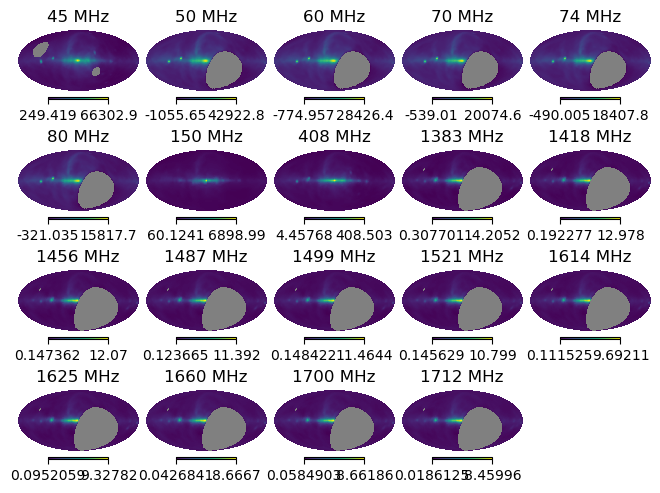

In [6]:
label ="north"
udgrade= True  


######################
hdul = fits.open(f"../inputmaps/coarse_{label}_maps_nside256.fits" ) 
df = pd.DataFrame()
cols = hdul[1].columns.names
cols = cols 
df['frequency'] = np.float64(cols  )/1e3
data = hdul[1].data

nfreq=len(cols)
mapserr_table = np.load(f"../inputmaps/coarse_{label}_errors_dict.npz")
errv = [v  for v in mapserr_table.values() ] 
df['depth_i']= errv 

instrument = df.dropna(axis=1, how='all')
hdul.close()


freq_maps=hp.read_map(f"../inputmaps/coarse_{label}_maps_nside256.fits",  field=cols  )

if udgrade:
    nside_new = 64
    
    noise_factor = np.sqrt(hp.nside2npix(hp.get_nside (freq_maps[0 ])) /hp.nside2npix( nside_new )  )
    instrument['depth_i'] /= noise_factor
    j=0
    freq_maps_ud=[]
    for i  in range(nfreq ):
    
        mask =np.isnan(freq_maps[i] )
        freq_maps[i][mask]=hp.UNSEEN 

        freq_maps_ud.append( hp.ud_grade(freq_maps[i] , nside_out=nside_new   ))
    freq_maps=np.vstack(freq_maps_ud)


freq_maps= freq_maps.reshape( freq_maps.shape[0],1,  freq_maps.shape[1])

print(instrument ) 
for i  in range(nfreq ):
    hp.mollview(   freq_maps[i,0  ]     , 
                 title=f'{cols[i] } MHz'  , 
                sub=(4,5,1+i) , notext=True)

In [25]:


nside = 64 
options={'disp':False , 'gtol': 1e-18, 'eps': 1e-18,   'maxiter': 1000, 'ftol': 1e-18 }
tol = 1e-18
method='TNC'
components =[  Synchrotron(nu0=0.045, running=None   ,   units='K_RJ'  ) , 
                  FreeFree(nu0=.408 ,  units='K_RJ'  ) 
                    ]


print(components[0].n_param, components[1].n_param , hp.get_nside(freq_maps[0,:,:]) )
nsidepatches = [nside, nside , nside ] #,nside    ]


#-------------   no maskfreq 

maskfreq= np.ma.masked_inside(df['frequency'],0.05 ,0.08).mask  
#instrument[~maskfreq], freq_maps[~maskfreq] 


3 1 64


## run north 

In [13]:
results   = sr.multi_res_comp_sep(components, instrument[~maskfreq], freq_maps[~maskfreq]  ,
                                  nsides= nsidepatches ,
                                    method=method,
                                    tol = tol,
                                     options=options,
                                    #bounds=bounds,
                                    )
#np.savez(f'../outputs/fgbuster_params_{label}_nside{nside}.npz',
#                  **{n: a for n, a in zip(results.params, results.x)})

(14, 1, 49152) (14, 1, 49152) (49152, 1, 2, 2)
(1, 49152)


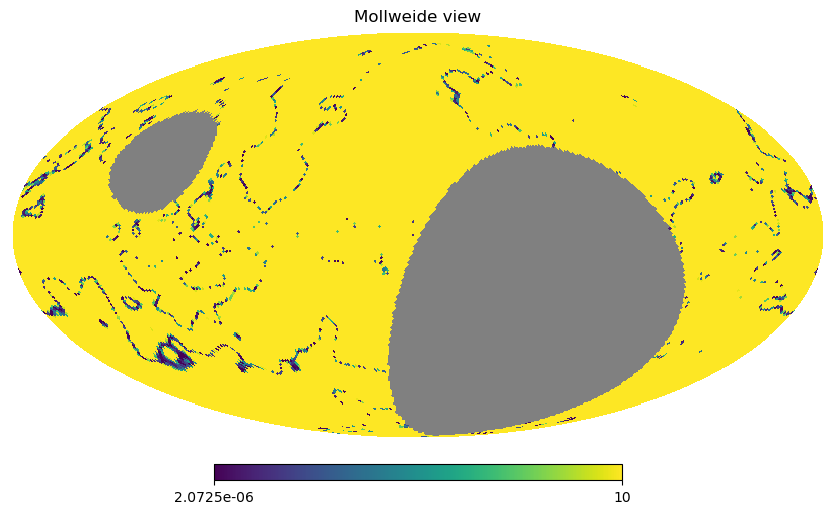

In [74]:
print(results.chi.shape, freq_maps[~maskfreq].shape , results.invAtNA.shape )
ndof =freq_maps[~maskfreq].shape[0] -len(results.params) 
chi2 =(results.chi).sum(axis=0) [0] **2
mask = results.x_map[0] == hp.UNSEEN
chi2[mask]=np.nan 
print(results.chi.sum(axis=0).shape) 
hp.mollview(chi2 /(ndof ) ,max=10    ) 
pl.show() 

In [53]:
results

   message: Linear search failed
   success: False
    status: 4
       fun: -152873811751479.25
         x: [array([-2.892e+00, -2.923e+00, ..., -2.717e+00, -2.315e+00],
                  shape=(49152,)), array([ 4.160e-03,  3.112e-03, ..., -2.017e-03,  1.862e-02],
                  shape=(49152,)), array([-2.296e+00, -2.263e+00, ..., -2.470e+00, -2.312e+00],
                  shape=(49152,))]
       nit: 357
       jac: [-2.826e+03 -2.721e+03 ...  7.419e+03  4.244e+05]
      nfev: 4496
         s: [[[ 6.480e+02  7.284e+02 ... -7.017e+02 -2.597e+03]]
            
             [[ 9.341e+00  8.999e+00 ...  1.339e+01  2.894e+01]]]
   invAtNA: [[[[ 5.216e-01 -7.247e-04]
               [-7.247e-04  1.133e-06]]]
            
            
             [[[ 4.903e-01 -6.116e-04]
               [-6.116e-04  8.849e-07]]]
            
            
             ...
            
            
             [[[ 1.205e+00 -2.755e-03]
               [-2.755e-03  6.443e-06]]]
            
            
  

In [68]:
hp.mollview( results.invAtNA[:,0,1,0])

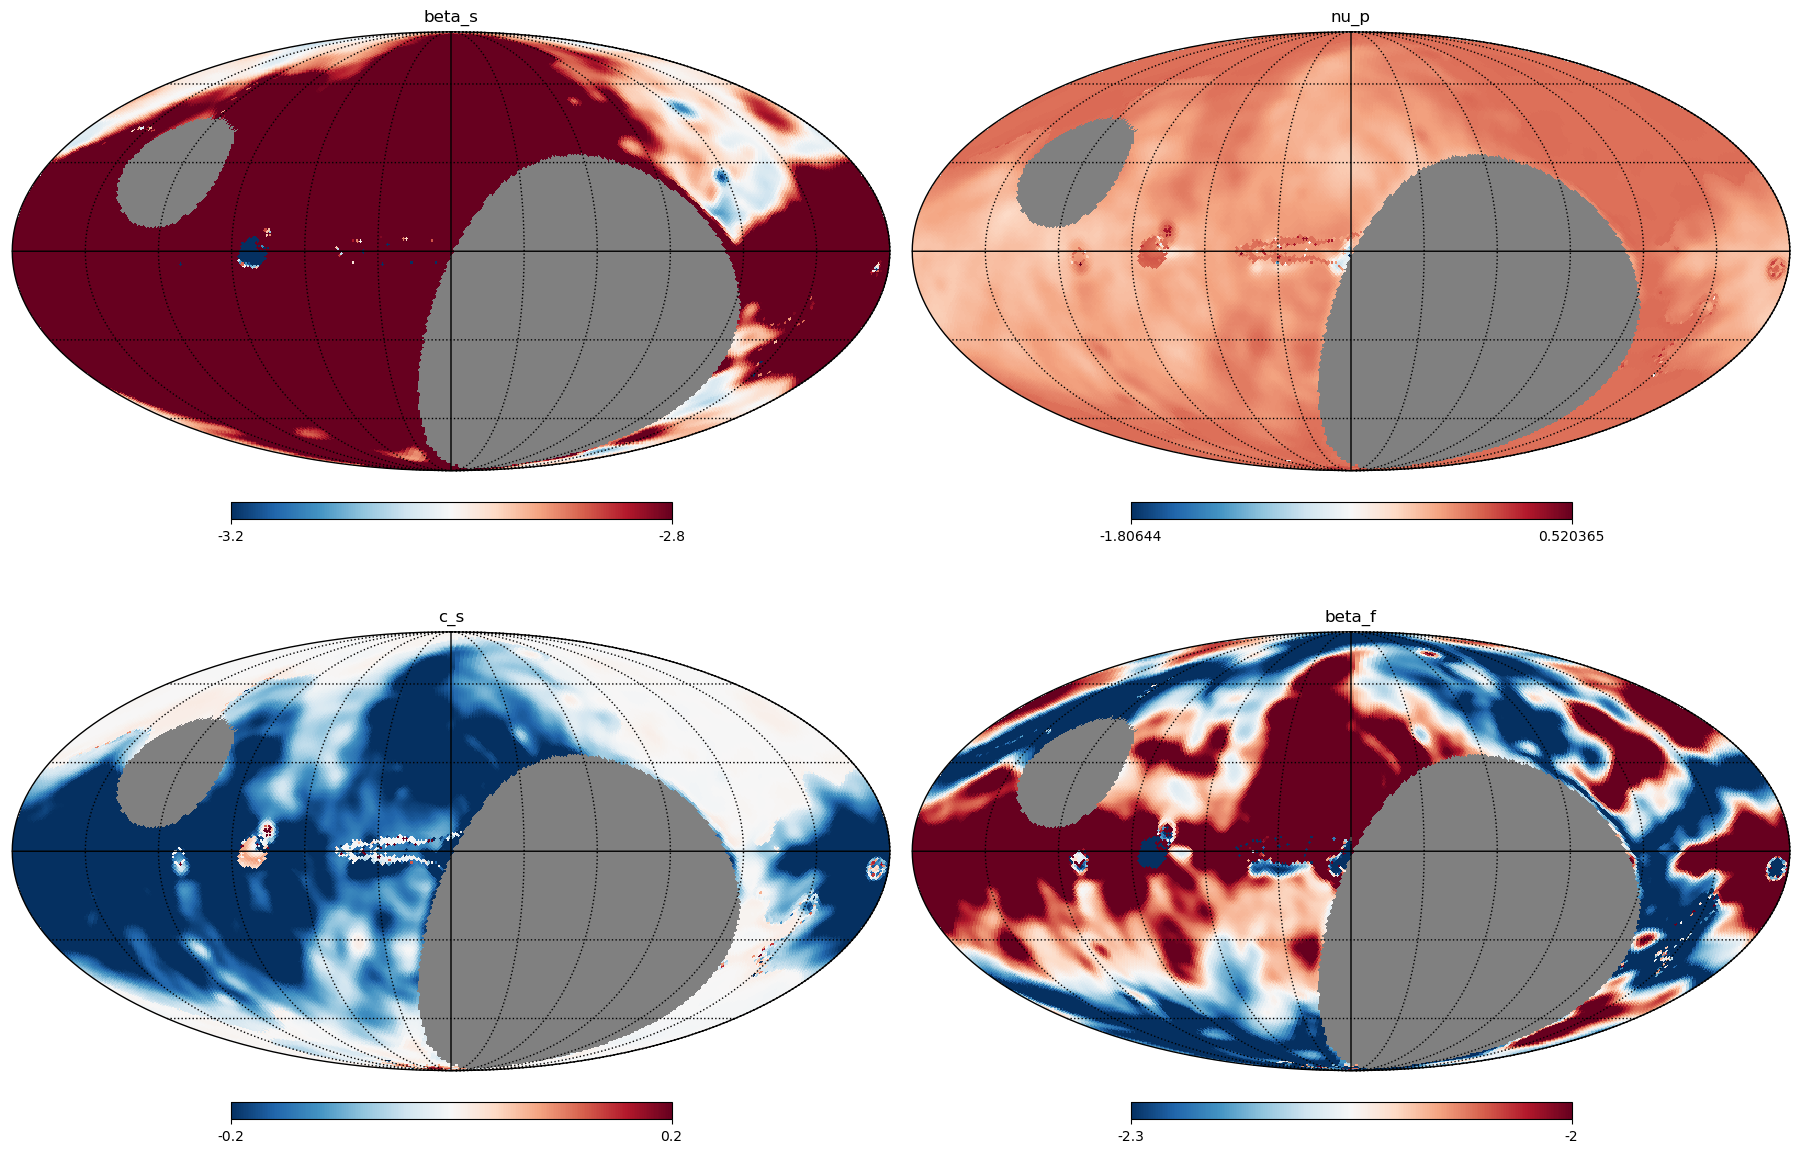

In [23]:
pl.figure( figsize=(18, 12))
"""
betas =  (results.x_map[0])  
nup =  (results.x_map[1])
print( nup[nup!= hp.UNSEEN ] .mean() ) 
cs =results.x_map[2]  
betaf =results.x_map[3]  
"""
betas =  (results.x_map[0])  
cs =results.x_map[1]  
betaf =results.x_map[2]  

hp.mollview(betas , title='beta_s' , cmap='RdBu_r', min=-3.2,max=-2.8,sub=221   )
hp.mollview(nup , title='nu_p' , cmap='RdBu_r' , sub=222)
hp.mollview(cs , title='c_s' , cmap='RdBu_r' , min=-0.2, max=0.2   , sub=223 )  
hp.mollview(betaf , title='beta_f' , cmap='RdBu_r', min=-2.3, max=-2.0 , sub=224)

hp.graticule () 

In [12]:
results.message

'Linear search failed'

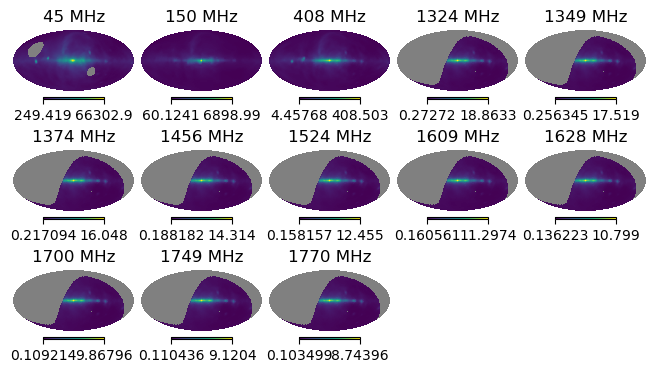

In [6]:
label ="south"
udgrade= True 


######################
hdul = fits.open(f"../inputmaps/coarse_{label}_maps_nside256.fits" ) 
df = pd.DataFrame()
cols = hdul[1].columns.names
cols = cols 
df['frequency'] = np.float_(cols  )/1e3
data = hdul[1].data

nfreq=len(cols)
mapserr_table = np.load(f"../inputmaps/coarse_{label}_errors_dict.npz")
errv = [v for v in mapserr_table.values() ] 
df['depth_i']= errv 
instrument = df.dropna(axis=1, how='all')
hdul.close()

freq_maps=hp.read_map(f"../inputmaps/coarse_{label}_maps_nside256.fits",  field=cols  )

if udgrade:
    nside_new = 64
    noise_factor = np.sqrt(hp.nside2npix(hp.get_nside (freq_maps[0 ])) /hp.nside2npix( nside_new )  )
    instrument['depth_i'] /= noise_factor
    j=0
    freq_maps_ud=[]
    for i  in range(nfreq ):
    
        mask =np.isnan(freq_maps[i] )
        freq_maps[i][mask]=hp.UNSEEN 

        freq_maps_ud.append( hp.ud_grade(freq_maps[i] , nside_out=nside_new   ))
    freq_maps=np.vstack(freq_maps_ud)


freq_maps= freq_maps.reshape( freq_maps.shape[0],1,  freq_maps.shape[1])


for i  in range(nfreq ):
    hp.mollview(   freq_maps[i,0  ]     , 
                 title=f'{cols[i] } MHz'  , 
                sub=(4,5,1+i) , notext=True)

In [14]:
instrument, hp.get_nside(freq_maps[0,:,:])

(    frequency   depth_i
 0       0.045      75.0
 1       0.150      10.0
 2       0.408     0.025
 3       1.324     0.004
 4       1.349  0.003888
 5       1.374  0.003776
 6       1.456  0.003408
 7       1.524  0.003103
 8       1.609  0.002722
 9       1.628  0.002637
 10      1.700  0.002314
 11      1.749  0.002094
 12      1.770     0.002,
 64)

## run south 

In [7]:

results   = sr.multi_res_comp_sep(components, instrument, freq_maps,  
                                  nsides= nsidepatches ,
                                    method=method,
                                    tol = tol,
                                     options=options,
                                    #bounds=bounds,
                                    )

np.savez(f'../outputs/fgbuster_params_{label}_nside{nside}.npz',
                  **{n: a for n, a in zip(results.params, results.x)})

SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> l

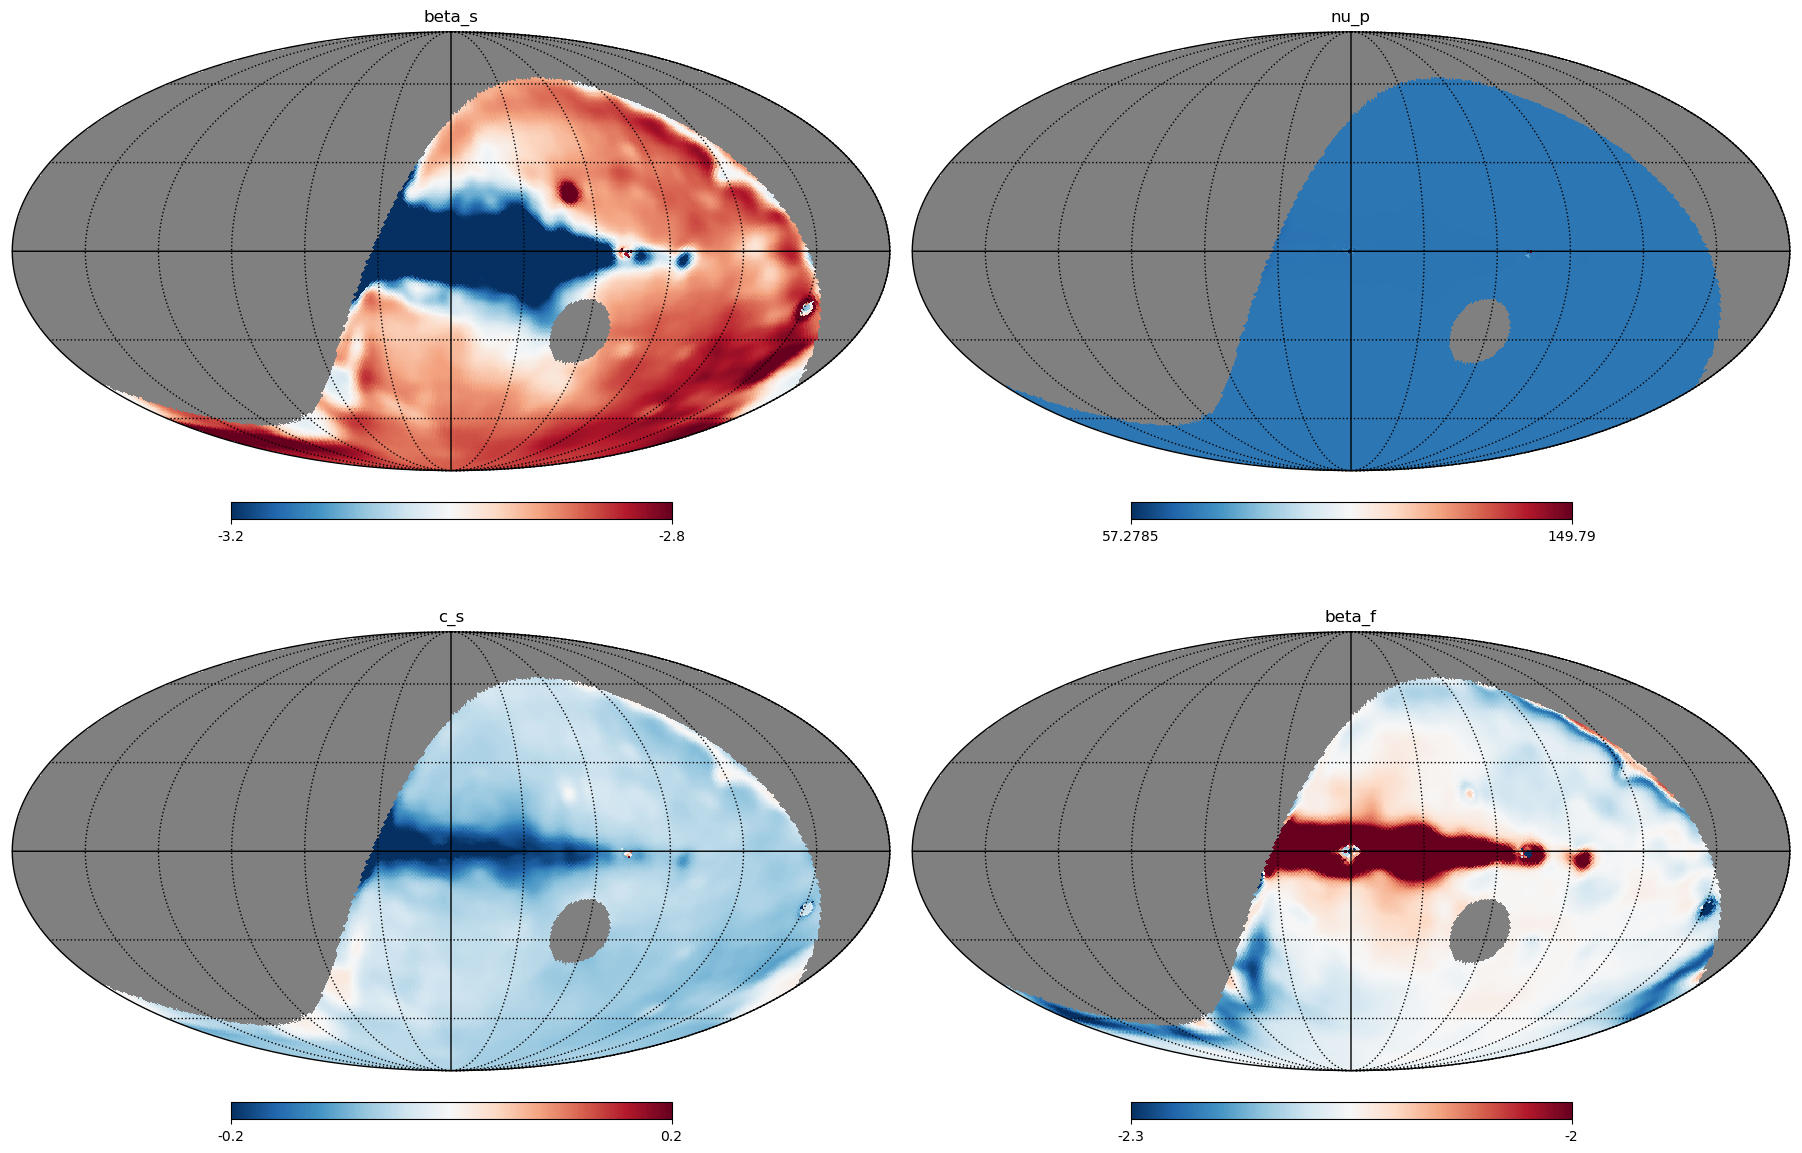

In [8]:
pl.figure( figsize=(18, 12))

betas =  (results.x_map[0])  
nup =  (results.x_map[1])
cs =results.x_map[2]  
betaf =results.x_map[3]  
hp.mollview(betas , title='beta_s' , cmap='RdBu_r', min=-3.2,max=-2.8,sub=221   )
hp.mollview(nup , title='nu_p' , cmap='RdBu_r' , sub=222)
hp.mollview(cs , title='c_s' , cmap='RdBu_r' , min=-0.2, max=0.2   , sub=223 )  
hp.mollview(betaf , title='beta_f' , cmap='RdBu_r', min=-2.3, max=-2.0 , sub=224)

hp.graticule() 

## combine data

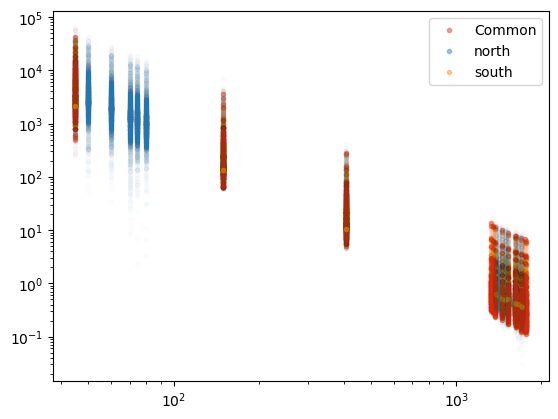

In [9]:
y = freq_maps[:,0,::200]

freqs = np.asarray(instrument['frequency'])

    # 1) scatter all samples (fast)
x = np.repeat(freqs[:, None], y.shape[1], axis=1)*1e3  # same shape as y
pl.semilogy (x, y ,f'C{3}.', alpha=0.4 )
pl.semilogy (x[:,0], y[:,0] ,f'C{3}.' , alpha=.4, label="Common" )
labels = ['north', 'south' ]
udgrade= False 
jj=0
for   label in  (labels):
    ######################
    hdul = fits.open(f"../inputmaps/coarse_{label}_maps_nside256.fits" ) 
    df = pd.DataFrame()
    cols = hdul[1].columns.names
    cols = cols 
    df['frequency'] = np.float_(cols  )/1e3
    data = hdul[1].data

    nfreq=len(cols)
    mapserr_table = np.load(f"../inputmaps/coarse_{label}_errors_dict.npz")
    errv = [v for v in mapserr_table.values() ] 
    df['depth_i']= errv 
    instrument = df.dropna(axis=1, how='all')
    hdul.close()

    freq_maps=hp.read_map(f"../inputmaps/coarse_{label}_maps_nside256.fits",  field=cols  )


    if udgrade:
        nside_new = 64
        noise_factor = np.sqrt(hp.nside2npix(hp.get_nside (freq_maps[0 ])) /hp.nside2npix( nside_new )  )
        instrument['depth_i'] /= noise_factor
        j=0
        freq_maps_ud=[]
        for i  in range(nfreq ):
        
            mask =np.isnan(freq_maps[i] )
            freq_maps[i][mask]=hp.UNSEEN 

            freq_maps_ud.append( hp.ud_grade(freq_maps[i] , nside_out=nside_new   ))
        freq_maps=np.vstack(freq_maps_ud)


    freq_maps= freq_maps.reshape( freq_maps.shape[0],1,  freq_maps.shape[1])
    y = freq_maps[:,0,::200]

    freqs = np.asarray(instrument['frequency'])

    # 1) scatter all samples (fast)
    x = np.repeat(freqs[:, None], y.shape[1], axis=1)*1e3  # same shape as y
    pl.semilogy (x, y ,f'C{jj}.', alpha=0.01 )
    pl.semilogy (x[:,0], y[:,0] ,f'C{jj}.' , alpha=.4, label=label )
    pl.legend() 
    pl.loglog() 

    jj+=1

50 0.09621491713942298
100 0.046644905664583215
150 0.027489239410153674
200 0.016979598653948207
250 0.010563309583777875
300 0.0065691231620983535
350 0.004081182172565444
396
50 0.04730215796643821
100 0.022457467493938833
140
50 0.01307011152538745
100 0.006142127865684619
150 0.003580704801018246
200 0.0022072298104287365
212
50 0.010692575770801627
100 0.0033282469768402094
136


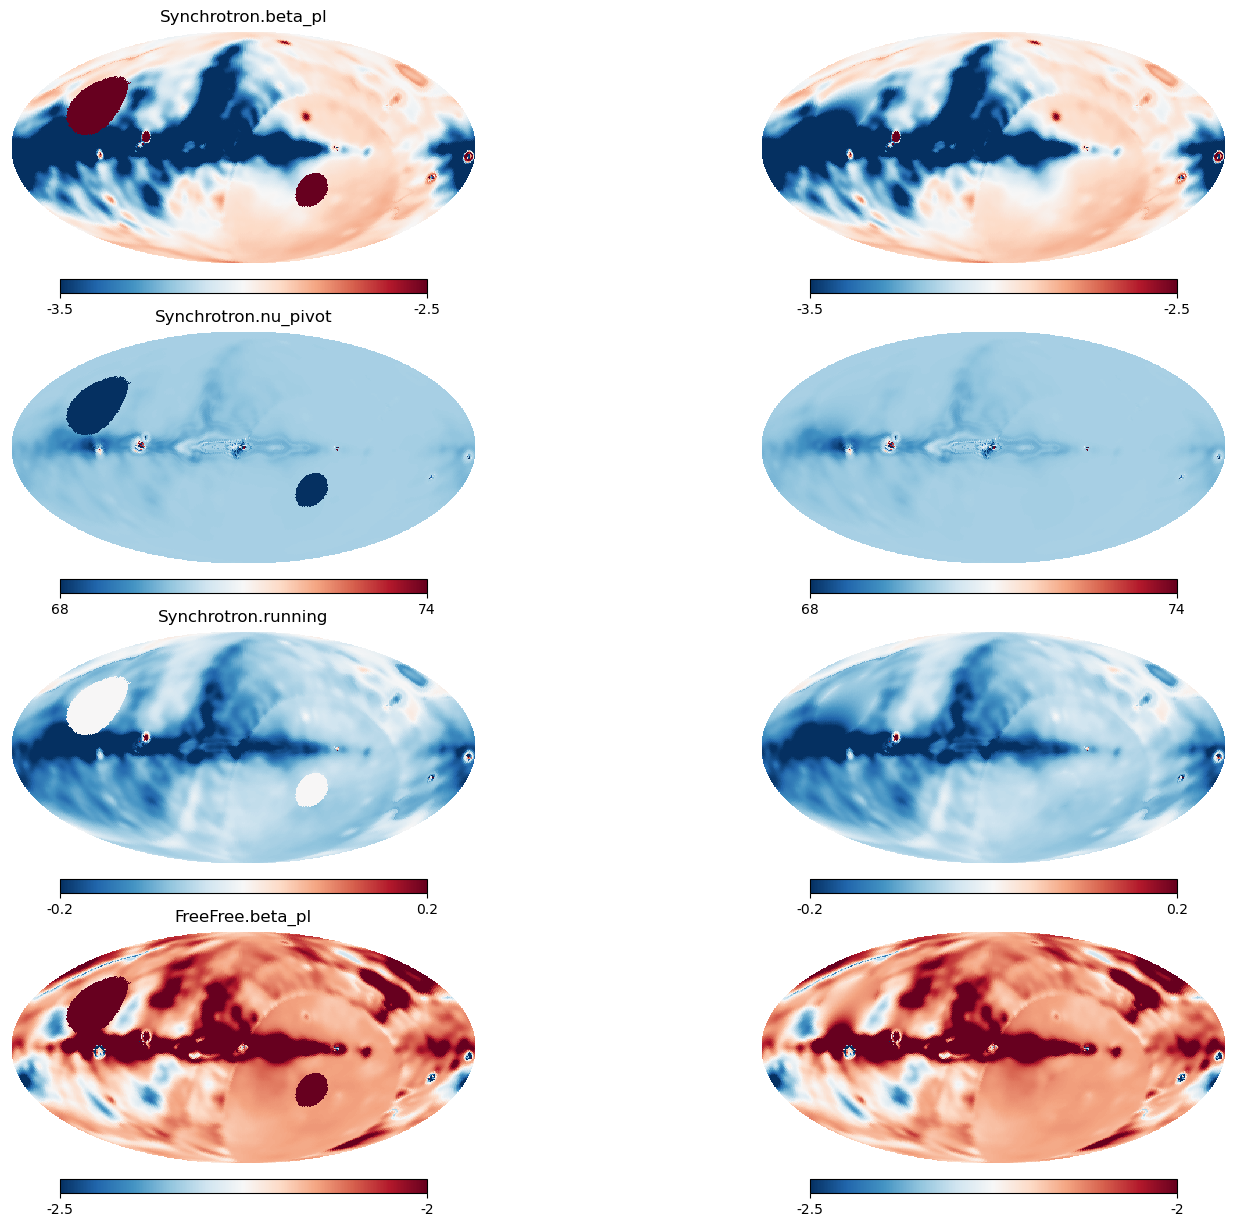

In [5]:
nside=64
common_apo =hp.read_map('../common_south_north_apo.fits' )
valid_north = hp.read_map(f"../valid_north_apo.fits" )
valid_south = hp.read_map(f"../valid_south_apo.fits" )
combined_dic ={} 

kk=0
pl.figure(figsize=(15,12)    )
for comp, comps  in zip(["Synchrotron", "FreeFree"], components):
    for p in comps.params: 
        
        if comp =="Synchrotron" and p=="running":
            min=-0.2
            max=0.2
        elif comp =="Synchrotron" and p=="beta_pl":
            min=-3.5
            max=-2.5

        elif comp =="FreeFree" and p=="beta_pl":
            min=-2.5
            max=-2.
        else: 
            min=68
            max=74 
        resnorth = np.load(f'../outputs/fgbuster_params_north_nside{nside}.npz' )[f"{comp}.{p}"]
        ressouth = np.load(f'../outputs/fgbuster_params_south_nside{nside}.npz' )[f"{comp}.{p}"]
        nan_north = resnorth == hp.UNSEEN
        nan_south = ressouth == hp.UNSEEN

        ressouth [nan_south]= 0. 
        resnorth [nan_north]= 0. 

        apo_pixs =np.logical_and( np.logical_or(np.ma.masked_inside(valid_north ,1e-14,.99999 ).mask   , np.ma.masked_inside(valid_south ,1e-14,.99999 ).mask  ), np.ma.masked_outside(common_apo ,1e-14 ,.99999 ).mask)  
        weigths =np.ones (ressouth.shape )+  (common_apo)  
        combined =   (ressouth *valid_south   + resnorth *valid_north  ) / ( weigths    )  
        combined[apo_pixs ]= ( ressouth[apo_pixs ] + resnorth[apo_pixs ] )   

        hp.mollview(combined  ,sub=421+kk , min=min, max=max, cmap='RdBu_r' , title=comp+"." +p )

        holes = np.where(combined == 0.  ) [0] 

        combined[holes]= np.nan 
        nside= hp.get_nside(combined)
        theta,phi = hp.pix2ang(ipix=holes, nside=nside, lonlat=False)
        neighbs = hp.get_all_neighbours(nside,theta,phi, lonlat=False)
        
          

        c=0
        while True:
            tmp = combined[holes].copy() 
            for jj, ipix in enumerate(holes) : 
                fill_neighb = ~pl.ma.masked_invalid(combined[neighbs[:, jj]] ).mask 
                
                combined[ipix] = pl.mean(combined[neighbs[fill_neighb, jj] ])
            if pl.allclose(combined[holes], tmp,atol=1e-4  ): break 
            c+=1

            if c%50==0: 
                print(c, pl.linalg.norm(combined[holes] - tmp ))  
                #pl.figure() 
                #hp.mollview(m-morig,sub=122) 
            #if c>500: break 

        print(c )
        hp.mollview(combined  ,sub=422+kk , min=min, max=max, cmap='RdBu_r', title= ''  )
        combined_dic[f"{comp}.{p}"]= combined 
        kk+=2

    
pl.show() 


In [12]:
np.savez(f'../outputs/fgbuster_filled_maps_nside{nside}_coarse.npz',
                  **{n: a for n, a in zip(combined_dic.keys(), combined_dic.values())}) 

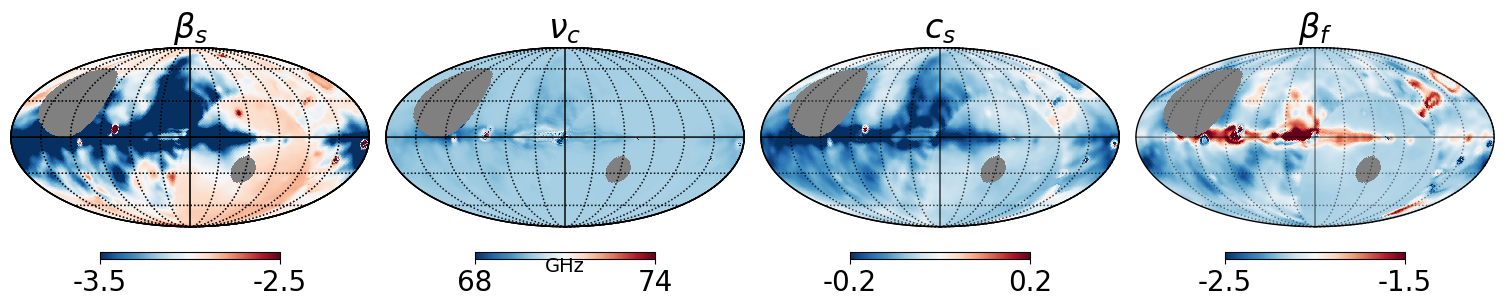

In [12]:
nside=64
common_apo =hp.read_map('../common_south_north_apo.fits' )
valid_north = hp.read_map(f"../valid_north_apo.fits" )
valid_south = hp.read_map(f"../valid_south_apo.fits" )
combined_dic ={} 

kk=0
pl.figure(figsize=(15,5)    )
import matplotlib
matplotlib.rcParams.update({'font.size': 20})
for comp, comps  in zip(["Synchrotron", "FreeFree"], components):
    for p in comps.params: 
        units=None 
        if comp =="Synchrotron" and p=="running":
            label = r'$c_s$' 
            min=-0.2
            max=0.2
        elif comp =="Synchrotron" and p=="beta_pl":
            label = r'$\beta_s$' 
            
            min=-3.5
            max=-2.5

        elif comp =="FreeFree" and p=="beta_pl":
            label = r'$\beta_f$' 
            
            min=-2.5
            max=-1.5
        else: 
            label = r'$\nu_c$' 
            units='GHz' 
            min=68
            max=74 
        resnorth = np.load(f'../outputs/fgbuster_params_north_nside{nside}.npz' )[f"{comp}.{p}"]
        ressouth = np.load(f'../outputs/fgbuster_params_south_nside{nside}.npz' )[f"{comp}.{p}"]
        nan_north = resnorth == hp.UNSEEN
        nan_south = ressouth == hp.UNSEEN

        ressouth [nan_south]= 0.
        resnorth [nan_north]= 0. 
        valid_south=1- valid_north 

        common_apo = np.ma.masked_outside (valid_north ,1e-14, .99999 ).mask 
        disc = hp.query_disc(nside, vec= hp.ang2vec (theta=np.pi/3   ,phi=2./3*np.pi +.04*np.pi   ) , radius =np.radians(30)  , )

        apo_pixs = (1-nan_north )*common_apo
        weigths =np.ones (ressouth.shape )#+  (common_apo)  
        combined =   (ressouth *valid_south   + resnorth *valid_north  ) / ( weigths    )  
        combined[disc ]= 0. #( ressouth[apo_pixs ] + resnorth[apo_pixs ] )   


        holes = np.where(combined == 0.  ) [0] 

        combined[holes]= np.nan 
        hp.mollview(combined  ,sub=141+kk ,title=label,  notext=False , unit=units, min=min, max=max, cmap='RdBu_r' )
        hp.graticule(alpha=.5) 
        kk+=1

pl.tight_layout() 
pl.savefig('fgb_coarse.pdf') 
pl.show()